In [1]:
#imports
import pandas as pd
import matplotlib.pyplot as plt

In [47]:
#kz Filter function
def kz_filter(df, window, iterations):
    """KZ filter implementation
    series is a pandas series modified from MONET 
    window is the filter window m in the units of the data (m = 2q+1)
    iterations is the number of times the moving average is evaluated """
    df.index = df.timestamp
    z = df.copy()
    for i in range(iterations):
        z.index = z.timestamp
        z = (
            z.rolling(window, center=True, min_periods=1)
            .mean()
            .reset_index()
            .dropna()
        )
    df = df.reset_index(drop=True)
    return z

In [43]:
def importThisSimple(colName,location):
    df = pd.read_csv(str(location))
    ds = pd.DataFrame()
    ds['timestamp'] = df['DATE']
    ds[str(colName)] = df[str(colName)]
    print(ds.head())

    return ds

In [3]:
#import dust data
df = pd.read_csv('/Users/emily/Documents/UMBC/Dr_LimaLab/FAUXCART/FAUXCART_Run1/40199099999_FAUCART.csv')
print(df.head())

   Unnamed: 0  Unnamed: 0.1      STATION                 DATE  SOURCE  \
0           0             0  40199099999  2001-01-01 00:00:00       4   
1           1             1  40199099999  2001-01-01 03:00:00       4   
2           2             2  40199099999  2001-01-01 03:50:00       4   
3           3             3  40199099999  2001-01-01 04:50:00       4   
4           4             4  40199099999  2001-01-01 05:50:00       4   

    LATITUDE  LONGITUDE  ELEVATION       NAME REPORT_TYPE  ...      ISD_flux  \
0  29.561281  34.960081       12.8  EILAT, IS       FM-12  ...  1.709347e-11   
1  29.561281  34.960081       12.8  EILAT, IS       FM-12  ...  2.792561e-10   
2  29.561281  34.960081       12.8  EILAT, IS       FM-15  ...  1.215970e-10   
3  29.561281  34.960081       12.8  EILAT, IS       FM-15  ...  7.183187e-11   
4  29.561281  34.960081       12.8  EILAT, IS       FM-15  ...  7.182887e-11   

  M2_recalculated_flux M2_original_flux   gwettop source_used  \
0         6.836

/opt/homebrew/Caskroom/miniconda/base/envs/research2/lib/python3.9/site-packages/IPython/core/interactiveshell.py:3266: DtypeWarning: Columns (10,25,28,30,31,32,33,41,43,44,45,46,47,48) have mixed types.Specify dtype option on import or set low_memory=False.
  has_raised = await self.run_ast_nodes(code_ast.body, cell_name,


In [14]:
#build simplified df to analyze 
data = pd.DataFrame()
data['timestamp'] = df['DATE']
data['OG_winds_correct_box'] = df['OG_winds_correct_box']
print(data.head())

             timestamp  OG_winds_correct_box
0  2001-01-01 00:00:00              2.649284
1  2001-01-01 03:00:00              4.076253
2  2001-01-01 03:50:00              4.076253
3  2001-01-01 04:50:00              4.164346
4  2001-01-01 05:50:00              3.861354


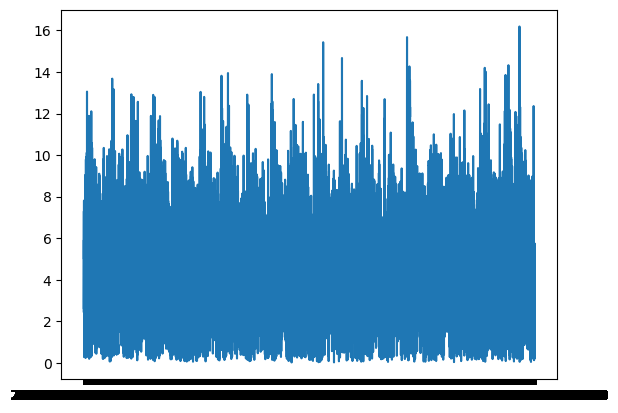

In [15]:
plt.plot(data['timestamp'], data['OG_winds_correct_box'])
plt.show()

In [16]:
#set window and iterations
window = 8760
iterations = 10
'''window is the filter window m in the units of the data (m = 2q+1),
iterations is the number of times the moving average is evaluated'''
z = kz_filter(data, 'monthly_average',window,iterations)

In [17]:
print(z.head())

             timestamp  OG_winds_correct_box
0  2001-01-01 00:00:00              4.643819
1  2001-01-01 03:00:00              4.643819
2  2001-01-01 03:50:00              4.643819
3  2001-01-01 04:50:00              4.643819
4  2001-01-01 05:50:00              4.643819


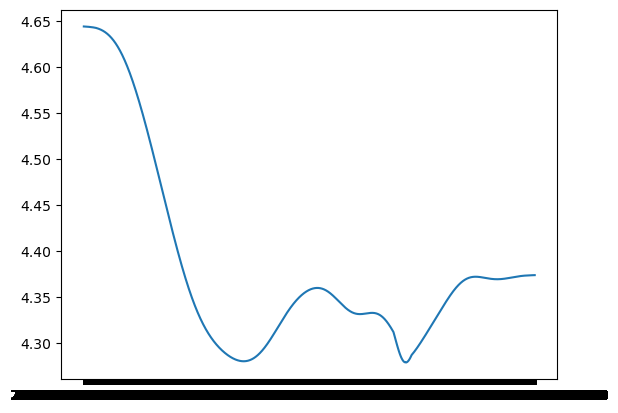

In [18]:
plt.plot(z['timestamp'], z['OG_winds_correct_box'])
plt.show()

In [19]:
#set window and iterations
window = 2160
iterations = 10
'''window is the filter window m in the units of the data (m = 2q+1),
iterations is the number of times the moving average is evaluated'''
z = kz_filter(data, 'monthly_average',window,iterations)

In [21]:
print(z.head())
print(z.tail())

             timestamp  OG_winds_correct_box
0  2001-01-01 00:00:00              4.414365
1  2001-01-01 03:00:00              4.414397
2  2001-01-01 03:50:00              4.414428
3  2001-01-01 04:50:00              4.414459
4  2001-01-01 05:50:00              4.414490
                  timestamp  OG_winds_correct_box
178271  2020-12-31 19:00:00              3.902513
178272  2020-12-31 20:00:00              3.902469
178273  2020-12-31 21:00:00              3.902425
178274  2020-12-31 22:00:00              3.902382
178275  2020-12-31 23:00:00              3.902339


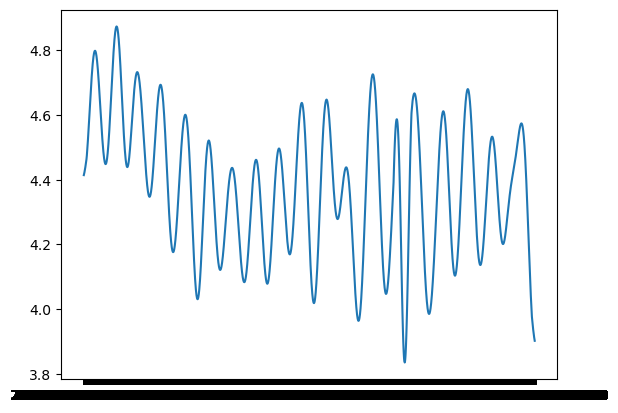

In [22]:
plt.plot(z['timestamp'], z['OG_winds_correct_box'])
plt.show()

In [24]:
#lets do our 4 test cases 
#Agree = 40356099999, Seasonal Bias = 40360099999, Flat Seasonality = 41055099999, M2 Overestimation = 41084099999
#import dust data
agree = pd.read_csv('/Users/emily/Documents/UMBC/Dr_LimaLab/FAUXCART/FAUXCART_Run1/40356099999_FAUCART.csv')
sb = pd.read_csv('/Users/emily/Documents/UMBC/Dr_LimaLab/FAUXCART/FAUXCART_Run1/40360099999_FAUCART.csv')
fs = pd.read_csv('/Users/emily/Documents/UMBC/Dr_LimaLab/FAUXCART/FAUXCART_Run1/41055099999_FAUCART.csv')
M2o = pd.read_csv('/Users/emily/Documents/UMBC/Dr_LimaLab/FAUXCART/FAUXCART_Run1/41084099999_FAUCART.csv')


/opt/homebrew/Caskroom/miniconda/base/envs/research2/lib/python3.9/site-packages/IPython/core/interactiveshell.py:3266: DtypeWarning: Columns (10,30,38,39,40,41,42,43,44,45,46,47,48,49,50) have mixed types.Specify dtype option on import or set low_memory=False.
  has_raised = await self.run_ast_nodes(code_ast.body, cell_name,
/opt/homebrew/Caskroom/miniconda/base/envs/research2/lib/python3.9/site-packages/IPython/core/interactiveshell.py:3266: DtypeWarning: Columns (10,23,28,30,31,32,40,41,42,43,44,45,46,47,48,49,50) have mixed types.Specify dtype option on import or set low_memory=False.
  has_raised = await self.run_ast_nodes(code_ast.body, cell_name,
/opt/homebrew/Caskroom/miniconda/base/envs/research2/lib/python3.9/site-packages/IPython/core/interactiveshell.py:3266: DtypeWarning: Columns (10,18,23,30,31,32,34,40,41,42,43,44,45,46,47,48,49,50,51) have mixed types.Specify dtype option on import or set low_memory=False.
  has_raised = await self.run_ast_nodes(code_ast.body, cell_name

In [26]:
#build simplified df to analyze 
agree_data = pd.DataFrame()
agree_data['timestamp'] = agree['DATE']
agree_data['OG_winds_correct_box'] = agree['OG_winds_correct_box']
print(agree_data.head())

sb_data = pd.DataFrame()
sb_data['timestamp'] = sb['DATE']
sb_data['OG_winds_correct_box'] = sb['OG_winds_correct_box']
print(sb_data.head())

sf_data = pd.DataFrame()
sf_data['timestamp'] = fs['DATE']
sf_data['OG_winds_correct_box'] = fs['OG_winds_correct_box']
print(sf_data.head())

M2o_data = pd.DataFrame()
M2o_data['timestamp'] = M2o['DATE']
M2o_data['OG_winds_correct_box'] = M2o['OG_winds_correct_box']
print(M2o_data.head())

             timestamp  OG_winds_correct_box
0  2001-01-01 01:00:00              3.655528
1  2001-01-01 02:00:00              3.805581
2  2001-01-01 03:00:00              4.000888
3  2001-01-01 05:00:00              5.853549
4  2001-01-01 07:00:00              6.355443
             timestamp  OG_winds_correct_box
0  2001-01-01 05:00:00              5.861233
1  2001-01-01 06:00:00              5.632889
2  2001-01-01 07:00:00              7.956063
3  2001-01-01 08:00:00              8.473208
4  2001-01-01 09:00:00              8.210492
             timestamp  OG_winds_correct_box
0  2001-01-01 05:50:00              2.518558
1  2001-01-01 06:00:00              1.950333
2  2001-01-01 07:00:00              2.381544
3  2001-01-01 08:00:00              2.821367
4  2001-01-01 09:00:00              3.329215
             timestamp  OG_winds_correct_box
0  2001-01-01 04:00:00              1.444595
1  2001-01-01 05:00:00              1.646046
2  2001-01-01 05:55:00              1.646046
3  2001-01

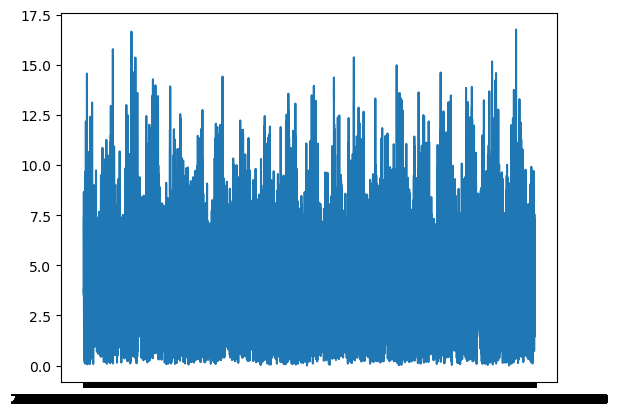

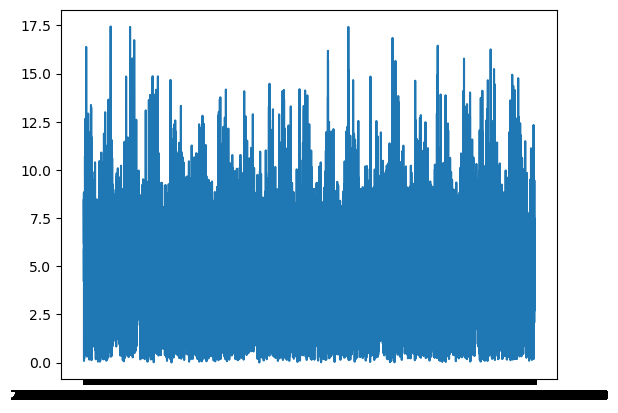

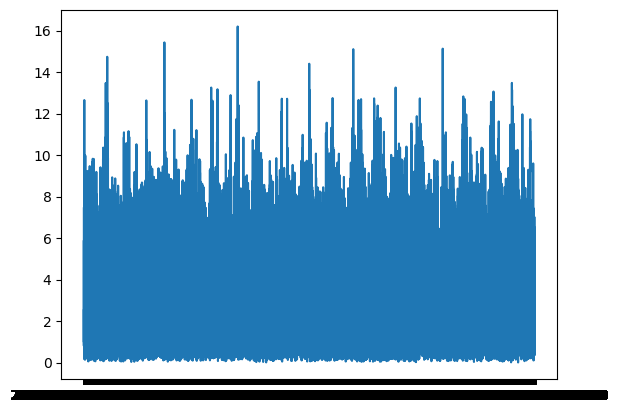

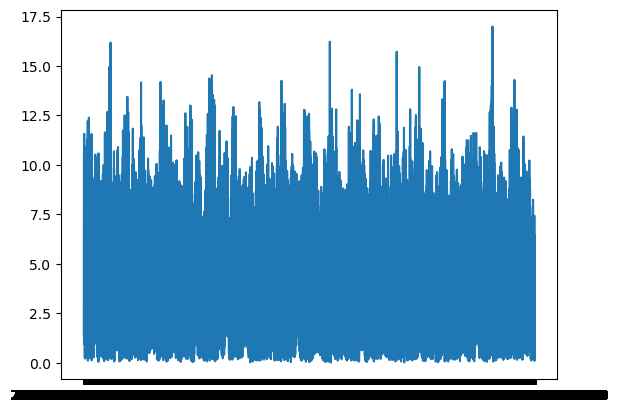

In [27]:
plt.plot(agree_data['timestamp'], agree_data['OG_winds_correct_box'])
plt.show()
plt.plot(sb_data['timestamp'], sb_data['OG_winds_correct_box'])
plt.show()
plt.plot(sf_data['timestamp'], sf_data['OG_winds_correct_box'])
plt.show()
plt.plot(M2o_data['timestamp'], M2o_data['OG_winds_correct_box'])
plt.show()

In [29]:
#set window and iterations
window = 2160 #seasonal
iterations = 10
'''window is the filter window m in the units of the data (m = 2q+1),
iterations is the number of times the moving average is evaluated'''
agree_z = kz_filter(agree_data, 'monthly_average',window,iterations)
sb_z = kz_filter(sb_data, 'monthly_average',window,iterations)
sf_z = kz_filter(sf_data, 'monthly_average',window,iterations)
M2o_z = kz_filter(M2o_data, 'monthly_average',window,iterations)

In [30]:
print(agree_z.head())
print(sb_z.head())
print(sf_z.head())
print(M2o_z.head())

             timestamp  OG_winds_correct_box
0  2001-01-01 01:00:00              4.264867
1  2001-01-01 02:00:00              4.264877
2  2001-01-01 03:00:00              4.264888
3  2001-01-01 05:00:00              4.264899
4  2001-01-01 07:00:00              4.264910
             timestamp  OG_winds_correct_box
0  2001-01-01 05:00:00              4.628210
1  2001-01-01 06:00:00              4.628229
2  2001-01-01 07:00:00              4.628249
3  2001-01-01 08:00:00              4.628269
4  2001-01-01 09:00:00              4.628289
             timestamp  OG_winds_correct_box
0  2001-01-01 05:50:00              4.016992
1  2001-01-01 06:00:00              4.016995
2  2001-01-01 07:00:00              4.016999
3  2001-01-01 08:00:00              4.017002
4  2001-01-01 09:00:00              4.017006
             timestamp  OG_winds_correct_box
0  2001-01-01 04:00:00              4.528865
1  2001-01-01 05:00:00              4.528879
2  2001-01-01 05:55:00              4.528893
3  2001-01

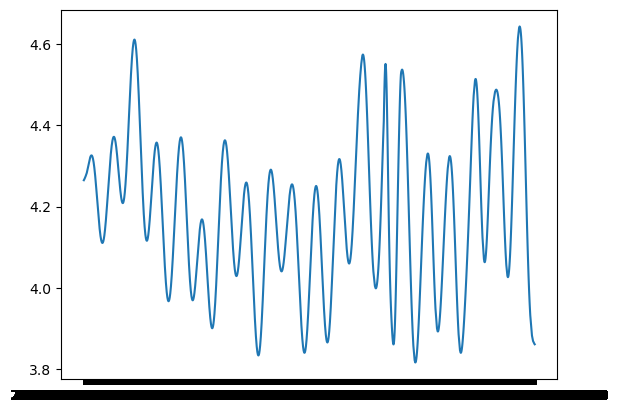

In [31]:
plt.plot(agree_z['timestamp'], agree_z['OG_winds_correct_box'])
plt.show()


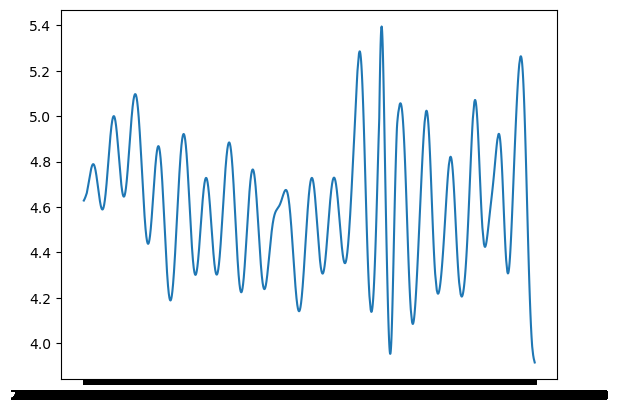

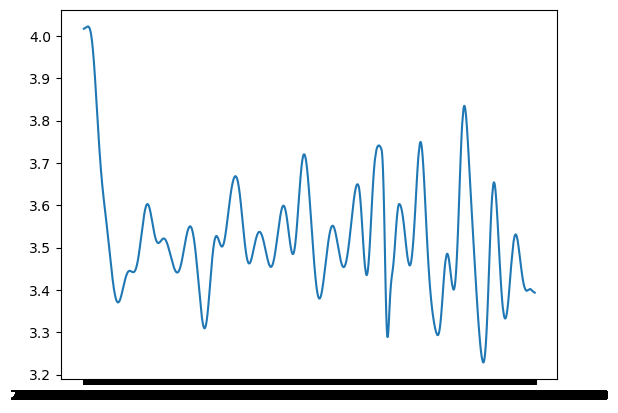

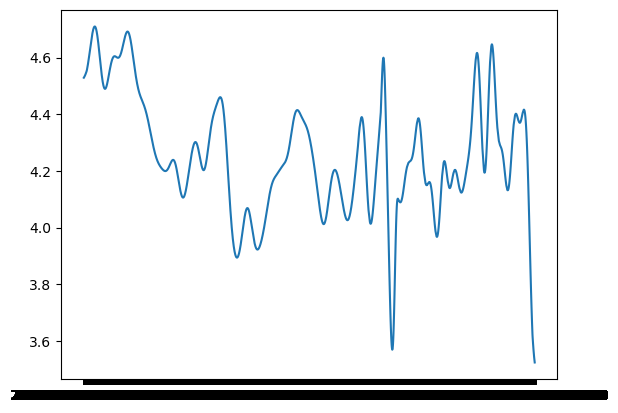

In [32]:
plt.plot(sb_z['timestamp'], sb_z['OG_winds_correct_box'])
plt.show()
plt.plot(sf_z['timestamp'], sf_z['OG_winds_correct_box'])
plt.show()
plt.plot(M2o_z['timestamp'], M2o_z['OG_winds_correct_box'])
plt.show()

In [33]:
#set window and iterations
window = 8640 #yearly
iterations = 10
'''window is the filter window m in the units of the data (m = 2q+1),
iterations is the number of times the moving average is evaluated'''
agree_z = kz_filter(agree_data, 'monthly_average',window,iterations)
sb_z = kz_filter(sb_data, 'monthly_average',window,iterations)
sf_z = kz_filter(sf_data, 'monthly_average',window,iterations)
M2o_z = kz_filter(M2o_data, 'monthly_average',window,iterations)

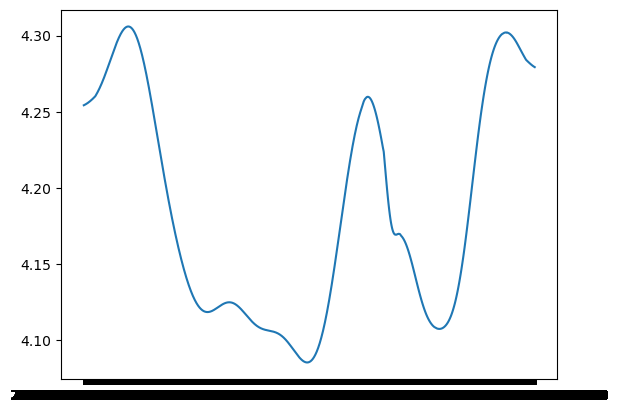

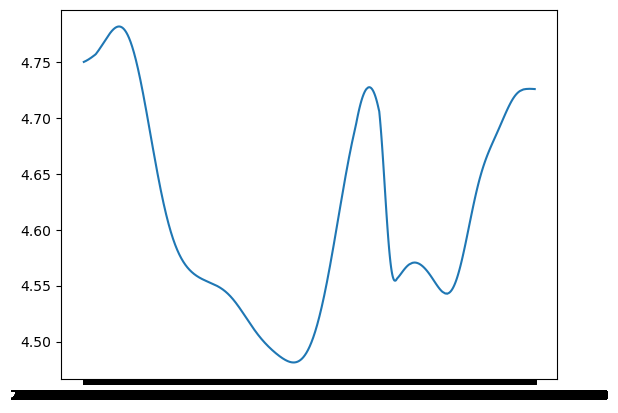

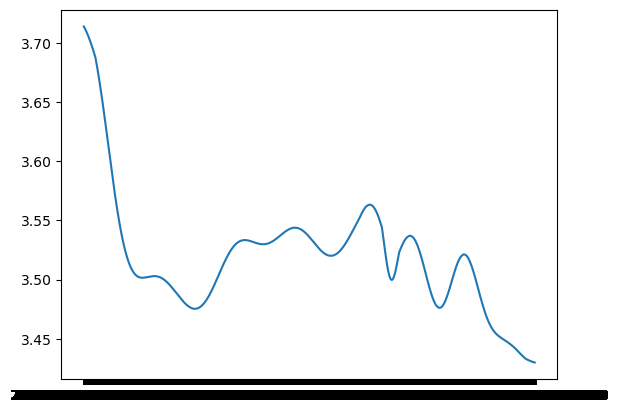

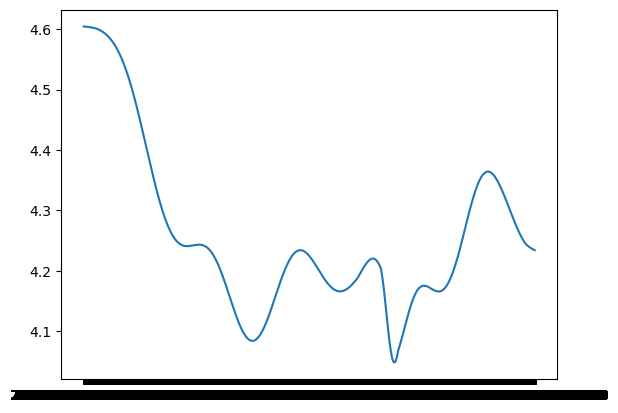

In [34]:
plt.plot(agree_z['timestamp'], agree_z['OG_winds_correct_box'])
plt.show()
plt.plot(sb_z['timestamp'], sb_z['OG_winds_correct_box'])
plt.show()
plt.plot(sf_z['timestamp'], sf_z['OG_winds_correct_box'])
plt.show()
plt.plot(M2o_z['timestamp'], M2o_z['OG_winds_correct_box'])
plt.show()

In [39]:
#set window and iterations
window = 24 #looking for diurnal cycle
iterations = 10
'''window is the filter window m in the units of the data (m = 2q+1),
iterations is the number of times the moving average is evaluated'''
agree_z = kz_filter(agree_data, 'monthly_average',window,iterations)
sb_z = kz_filter(sb_data, 'monthly_average',window,iterations)
sf_z = kz_filter(sf_data, 'monthly_average',window,iterations)
M2o_z = kz_filter(M2o_data, 'monthly_average',window,iterations)

In [56]:
plt.plot(agree_z['timestamp'], agree_z['OG_winds_correct_box'])
plt.show()
plt.plot(sb_z['timestamp'], sb_z['OG_winds_correct_box'])
plt.show()
plt.plot(sf_z['timestamp'], sf_z['OG_winds_correct_box'])
plt.show()
plt.plot(M2o_z['timestamp'], M2o_z['OG_winds_correct_box'])
plt.show()

KeyError: 'OG_winds_correct_box'

In [41]:
'''ISD Wind speed'''

'ISD Wind speed'

In [55]:
agree_data = importThisSimple('Speed_ISD','/Users/emily/Documents/UMBC/Dr_LimaLab/FAUXCART/FAUXCART_Run1/40356099999_FAUCART.csv')
sb_data = importThisSimple('Speed_ISD','/Users/emily/Documents/UMBC/Dr_LimaLab/FAUXCART/FAUXCART_Run1/40360099999_FAUCART.csv')
fs_data = importThisSimple('Speed_ISD','/Users/emily/Documents/UMBC/Dr_LimaLab/FAUXCART/FAUXCART_Run1/41055099999_FAUCART.csv')
M2o_data = importThisSimple('Speed_ISD','/Users/emily/Documents/UMBC/Dr_LimaLab/FAUXCART/FAUXCART_Run1/41084099999_FAUCART.csv') 

/opt/homebrew/Caskroom/miniconda/base/envs/research2/lib/python3.9/site-packages/IPython/core/interactiveshell.py:3445: DtypeWarning: Columns (10,30,38,39,40,41,42,43,44,45,46,47,48,49,50) have mixed types.Specify dtype option on import or set low_memory=False.
  if await self.run_code(code, result, async_=asy):


             timestamp  Speed_ISD
0  2001-01-01 01:00:00        3.1
1  2001-01-01 02:00:00        3.1
2  2001-01-01 03:00:00        3.1
3  2001-01-01 05:00:00        3.1
4  2001-01-01 07:00:00        2.1


/opt/homebrew/Caskroom/miniconda/base/envs/research2/lib/python3.9/site-packages/IPython/core/interactiveshell.py:3445: DtypeWarning: Columns (10,23,28,30,31,32,40,41,42,43,44,45,46,47,48,49,50) have mixed types.Specify dtype option on import or set low_memory=False.
  if await self.run_code(code, result, async_=asy):


             timestamp  Speed_ISD
0  2001-01-01 05:00:00        1.0
1  2001-01-01 06:00:00        1.0
2  2001-01-01 07:00:00        3.1
3  2001-01-01 08:00:00        5.1
4  2001-01-01 09:00:00        8.2


/opt/homebrew/Caskroom/miniconda/base/envs/research2/lib/python3.9/site-packages/IPython/core/interactiveshell.py:3445: DtypeWarning: Columns (10,18,23,30,31,32,34,40,41,42,43,44,45,46,47,48,49,50,51) have mixed types.Specify dtype option on import or set low_memory=False.
  if await self.run_code(code, result, async_=asy):


             timestamp  Speed_ISD
0  2001-01-01 05:50:00        0.0
1  2001-01-01 06:00:00        0.0
2  2001-01-01 07:00:00        0.0
3  2001-01-01 08:00:00        3.1
4  2001-01-01 09:00:00        2.6


/opt/homebrew/Caskroom/miniconda/base/envs/research2/lib/python3.9/site-packages/IPython/core/interactiveshell.py:3445: DtypeWarning: Columns (10,24,31,32,33,41,42,43,44,45,46,47,48,49,50) have mixed types.Specify dtype option on import or set low_memory=False.
  if await self.run_code(code, result, async_=asy):


             timestamp  Speed_ISD
0  2001-01-01 04:00:00        1.0
1  2001-01-01 05:00:00        1.0
2  2001-01-01 05:55:00        1.0
3  2001-01-01 06:00:00        1.0
4  2001-01-01 06:55:00        1.0


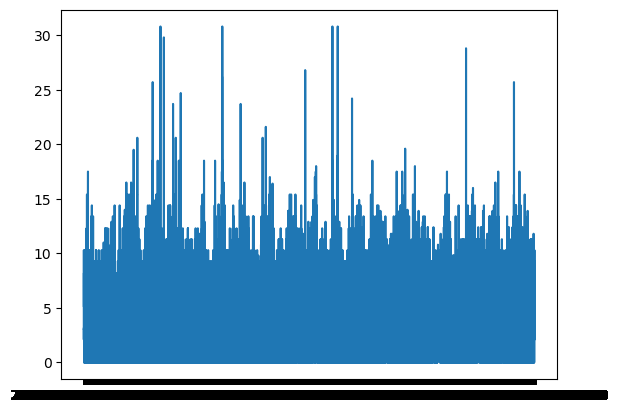

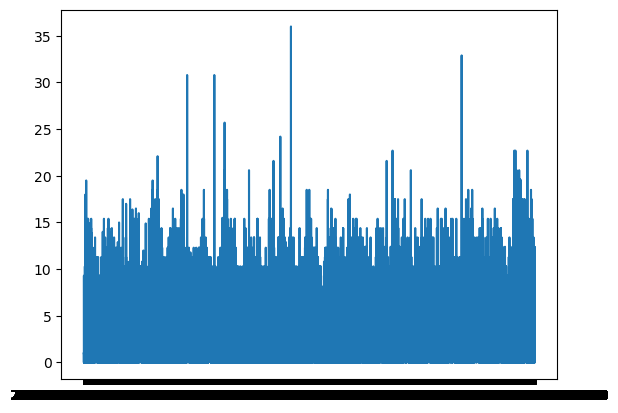

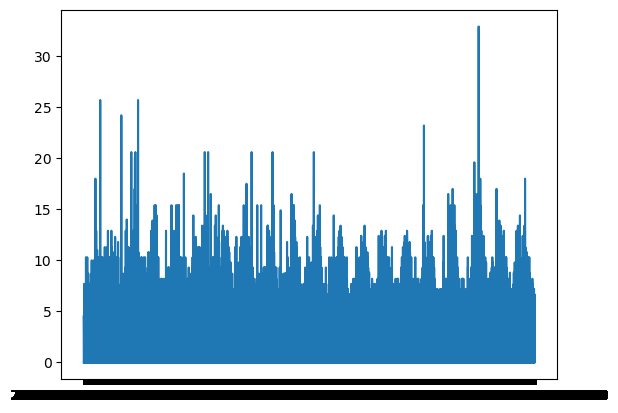

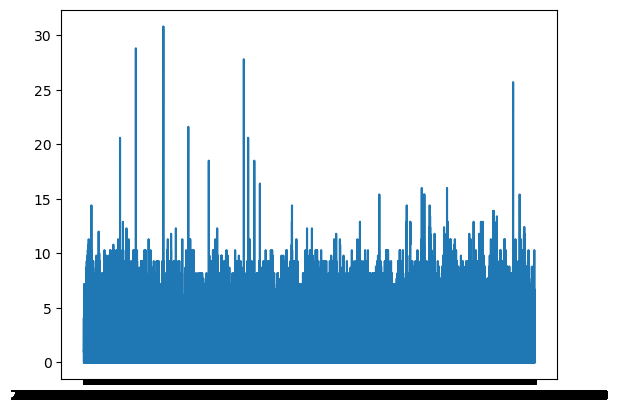

In [45]:
plt.plot(agree_data['timestamp'], agree_data['Speed_ISD'])
plt.show()
plt.plot(sb_data['timestamp'], sb_data['Speed_ISD'])
plt.show()
plt.plot(fs_data['timestamp'], fs_data['Speed_ISD'])
plt.show()
plt.plot(M2o_data['timestamp'], M2o_data['Speed_ISD'])
plt.show()

In [61]:
#set window and iterations
window = 2160
iterations = 10
'''window is the filter window m in the units of the data (m = 2q+1),
iterations is the number of times the moving average is evaluated'''
agree_z = kz_filter(agree_data,window,iterations)
sb_z = kz_filter(sb_data,window,iterations)
sf_z = kz_filter(sf_data,window,iterations)
M2o_z = kz_filter(M2o_data,window,iterations)

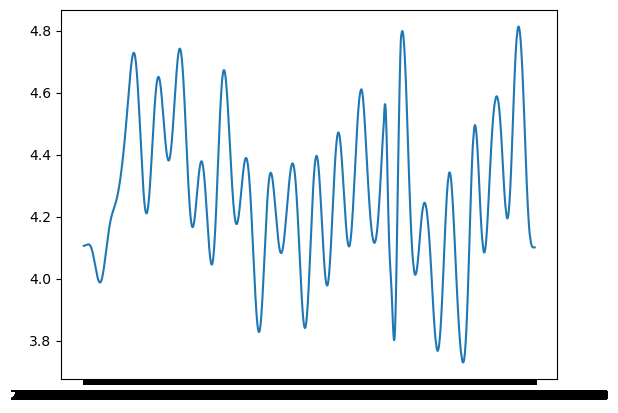

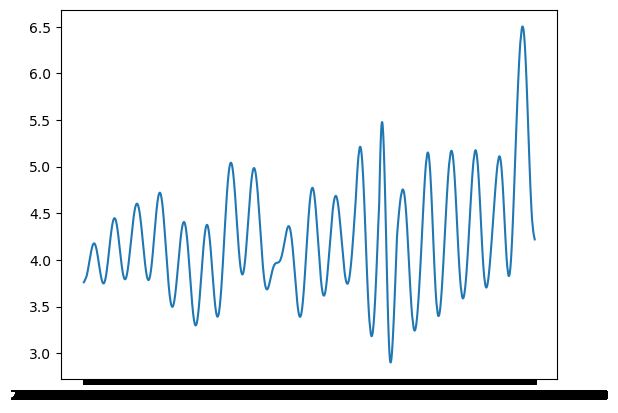

KeyError: 'Speed_ISD'

In [49]:
plt.plot(agree_z['timestamp'], agree_z['Speed_ISD'])
plt.show()
plt.plot(sb_z['timestamp'], sb_z['Speed_ISD'])
plt.show()


             timestamp  Speed_ISD
0  2001-01-01 05:50:00        0.0
1  2001-01-01 06:00:00        0.0
2  2001-01-01 07:00:00        0.0
3  2001-01-01 08:00:00        3.1
4  2001-01-01 09:00:00        2.6


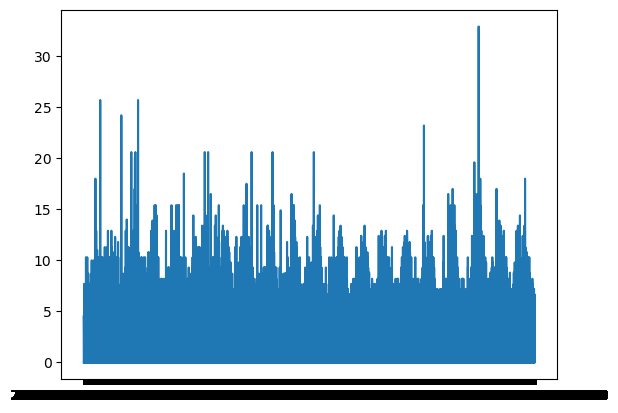

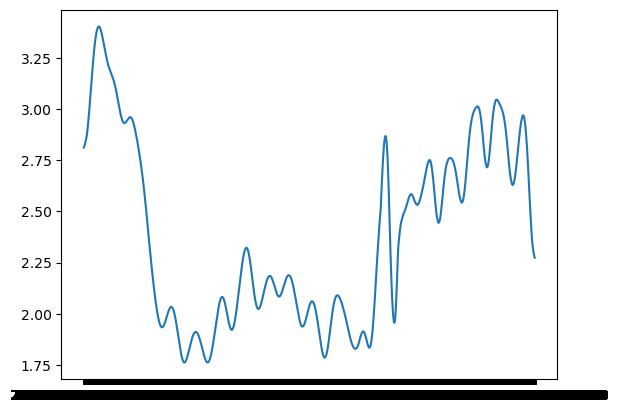

In [62]:
print(fs_data.head())
plt.plot(fs_data['timestamp'], fs_data['Speed_ISD'])
plt.show()
plt.plot(M2o_z['timestamp'], M2o_z['Speed_ISD'])
plt.show()

In [63]:
#set window and iterations
window = 8640
iterations = 10
'''window is the filter window m in the units of the data (m = 2q+1),
iterations is the number of times the moving average is evaluated'''
agree_z = kz_filter(agree_data,window,iterations)
sb_z = kz_filter(sb_data,window,iterations)
sf_z = kz_filter(sf_data,window,iterations)
M2o_z = kz_filter(M2o_data,window,iterations)

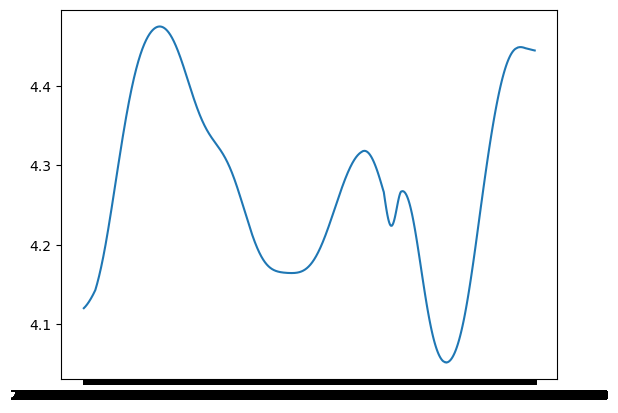

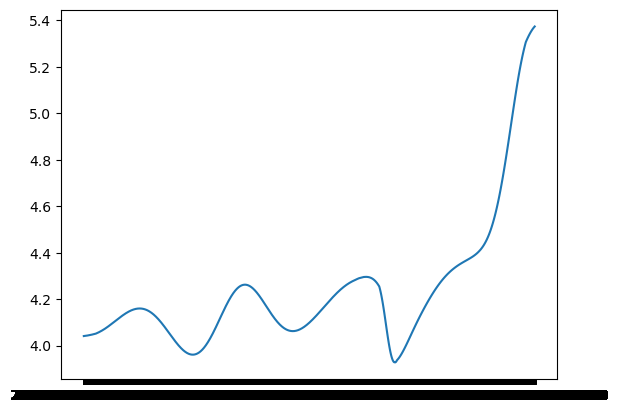

KeyError: 'Speed_ISD'

In [64]:
plt.plot(agree_z['timestamp'], agree_z['Speed_ISD'])
plt.show()
plt.plot(sb_z['timestamp'], sb_z['Speed_ISD'])
plt.show()


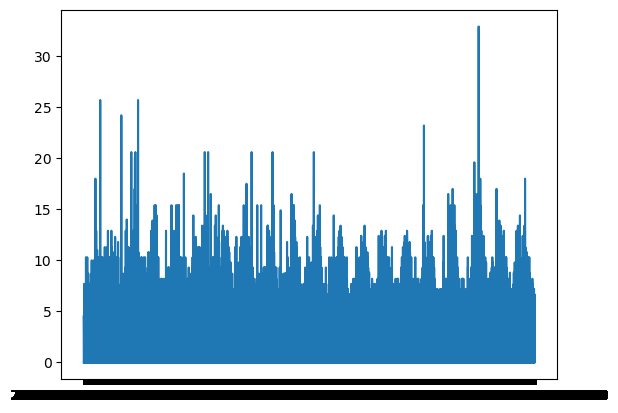

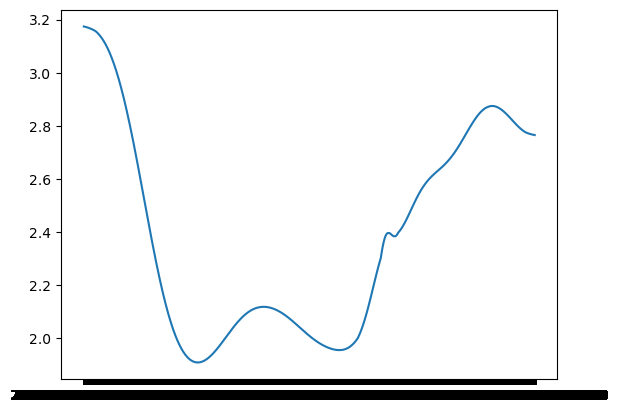

In [65]:
plt.plot(fs_data['timestamp'], fs_data['Speed_ISD'])
plt.show()
plt.plot(M2o_z['timestamp'], M2o_z['Speed_ISD'])
plt.show()

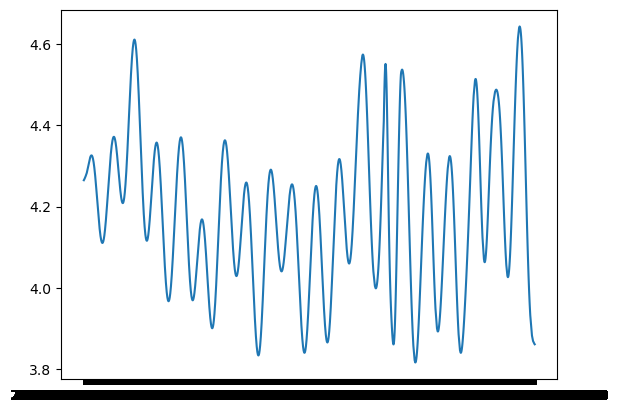

In [ ]:
plt.plot(agree_z['timestamp'], agree_z['OG_winds_correct_box'])
plt.show()


In [66]:
#set window and iterations
window = 24
iterations = 10
'''window is the filter window m in the units of the data (m = 2q+1),
iterations is the number of times the moving average is evaluated'''
agree_z = kz_filter(agree_data,window,iterations)
sb_z = kz_filter(sb_data,window,iterations)
sf_z = kz_filter(sf_data,window,iterations)
M2o_z = kz_filter(M2o_data,window,iterations)

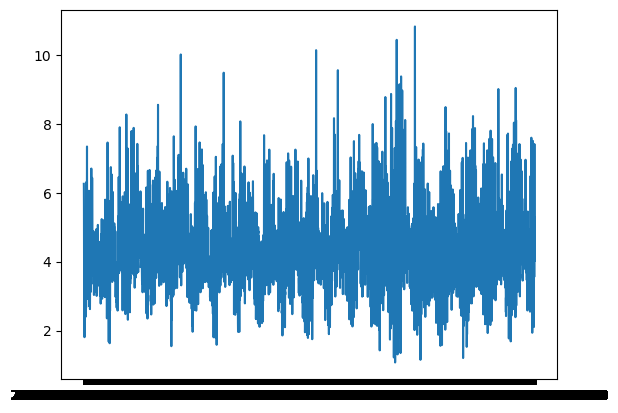

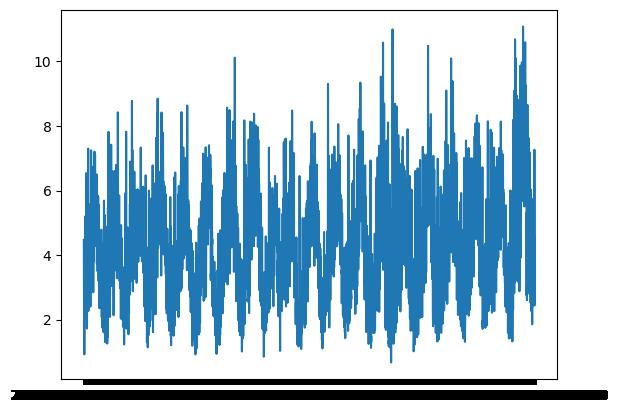

KeyError: 'Speed_ISD'

In [67]:
plt.plot(agree_z['timestamp'], agree_z['Speed_ISD'])
plt.show()
plt.plot(sb_z['timestamp'], sb_z['Speed_ISD'])
plt.show()
plt.plot(sf_z['timestamp'], sf_z['Speed_ISD'])
plt.show()
plt.plot(M2o_z['timestamp'], M2o_z['Speed_ISD'])
plt.show()